In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **Prepare Dataset**

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nguyenthuthuyn/trashnet-taco2")

print("Path to dataset files:", path)

100%|██████████| 481M/481M [00:03<00:00, 133MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/nguyenthuthuyn/trashnet-taco2/versions/1


In [5]:
import os

for root, dirs, files in os.walk(path):
    print(root)

/root/.cache/kagglehub/datasets/nguyenthuthuyn/trashnet-taco2/versions/1
/root/.cache/kagglehub/datasets/nguyenthuthuyn/trashnet-taco2/versions/1/train
/root/.cache/kagglehub/datasets/nguyenthuthuyn/trashnet-taco2/versions/1/train/labels
/root/.cache/kagglehub/datasets/nguyenthuthuyn/trashnet-taco2/versions/1/train/images
/root/.cache/kagglehub/datasets/nguyenthuthuyn/trashnet-taco2/versions/1/test
/root/.cache/kagglehub/datasets/nguyenthuthuyn/trashnet-taco2/versions/1/test/labels
/root/.cache/kagglehub/datasets/nguyenthuthuyn/trashnet-taco2/versions/1/test/images
/root/.cache/kagglehub/datasets/nguyenthuthuyn/trashnet-taco2/versions/1/valid
/root/.cache/kagglehub/datasets/nguyenthuthuyn/trashnet-taco2/versions/1/valid/labels
/root/.cache/kagglehub/datasets/nguyenthuthuyn/trashnet-taco2/versions/1/valid/images


In [3]:
import yaml
import os

# Nội dung data.yaml mới
yaml_content = """
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 59
names: ['aerosol', 'aluminium_blister_pack', 'aluminium_foil', 'battery', 'bott', 'broken_glass', 'carded_blister_pack', 'cigarette', 'clear_plastic_bottle', 'corrugated_carton', 'crisp_packet', 'disposable_food_container', 'disposable_plastic_cup', 'drink_can', 'drink_carton', 'egg_carton', 'foam_cup', 'foam_food_container', 'food_can', 'food_waste', 'garbage_bag', 'glass_bottle', 'glass_cup', 'glass_jar', 'magazine_paper', 'meal_carton', 'metal_bottle_cap', 'metal_lid', 'normal_paper', 'other_carton', 'other_plastic', 'other_plastic_bottle', 'other_plastic_container', 'other_plastic_cup', 'other_plastic_wrapper', 'paper_bag', 'paper_cup', 'paper_straw', 'pizza_box', 'plastic_bottle_cap', 'plastic_film', 'plastic_glooves', 'plastic_lid', 'plastic_straw', 'plastic_utensils', 'polypropylene_bag', 'pop_tab', 'scrap_metal', 'shoe', 'single-use_carrier_bag', 'six_pack_rings', 'spread_tub', 'squeezable_tube', 'styrofoam_piece', 'tissues', 'toilet_tube', 'trash', 'tupperware', 'wrapping_paper']

roboflow:
  workspace: nguyen-thu-thuy
  project: taco-trash_t
  version: 2
  license: CC BY 4.0
  url: https://universe.roboflow.com/nguyen-thu-thuy/taco-trash_t/dataset/2
"""

# Path lưu data.yaml
yolo_yaml_path = "/content/data.yaml"

# Tạo thư mục nếu chưa có
os.makedirs(os.path.dirname(yolo_yaml_path), exist_ok=True)

# Ghi file
with open(yolo_yaml_path, 'w') as f:
    f.write(yaml_content)

print(f"data.yaml file created at: {yolo_yaml_path}")

data.yaml file created at: /content/data.yaml


In [4]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 30.3 MB/s eta 0:00:00


## **Model and training**

In [6]:
from ultralytics import YOLO
import os

# Load a model
model = YOLO("yolov8s.pt")  # load a pretrained model

# Define the correct path to the data.yaml file
yolo_yaml_path = os.path.join("/root/.cache/kagglehub/datasets/nguyenthuthuyn/trashnet-taco2/versions/1", "data.yaml")

# Train the model
results = model.train(
    data=yolo_yaml_path,      # dataset 10k/59 lớp
    epochs=50,                # 50
    imgsz=480,                # size
    batch=48,                 # 48
    optimizer="AdamW",        # optimizer hiện đại, tốt cho generalization
    lr0=1e-3,                 # learning rate khởi đầu, hạ xuống 5e-4 nếu loss dao động
    cache=True,               # cache images để tăng tốc
    patience=20,              # early stopping sau 20 epoch không cải thiện val mAP
    plots=True,               # hiển thị đồ thị training
    pretrained=True           # khởi đầu từ YOLOv8s pretrained weights
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.209 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=48, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/root/.cache/kagglehub/datasets/nguyenthuthuyn/trashnet-taco2/versions/1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.

In [7]:
import shutil
import os

source_path = '/content/runs/detect/train/weights/best.pt'
destination_path = '/content/drive/MyDrive/yolov8s_trash/best10k59cls.pt'

# Create the destination directory if it doesn't exist
os.makedirs(os.path.dirname(destination_path), exist_ok=True)

shutil.copy(source_path, destination_path)
print(f"File copied to {destination_path}")

File copied to /content/drive/MyDrive/yolov8s_trash/best10k59cls.pt


## **Evaluate**

In [8]:
model_path = '/content/drive/MyDrive/yolov8s_trash/best10k59cls.pt'
model = YOLO(model_path)
metrics = model.val()

Ultralytics 8.3.209 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,148,417 parameters, 0 gradients, 28.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 29.7±19.6 MB/s, size: 77.6 KB)
val: Scanning /root/.cache/kagglehub/datasets/nguyenthuthuyn/trashnet-taco2/versions/1/valid/labels.cache... 387 images, 30 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 387/387 648.2Kit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 1354, len(boxes) = 1535. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 4.2it/s 5.9s
                   all        387       1535      0.349     0.0749     0.0795     0.0604
               aerosol          3          6          1          0      0.

In [12]:
# Show val detect
import matplotlib.pyplot as plt

# Labels
print("Labels:")
img = plt.imread("/content/runs/detect/val/val_batch0_labels.jpg")
plt.figure(figsize=(18, 18))
plt.imshow(img)
plt.axis('off')
plt.show()

# Pred
print("\nPred:")
img = plt.imread("/content/runs/detect/val/val_batch0_pred.jpg")
plt.figure(figsize=(18, 18))
plt.imshow(img)
plt.axis('off')
plt.show()

Output hidden; open in https://colab.research.google.com to view.

## **Show result**

In [ ]:
from ultralytics import YOLO


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.



image 1/1 /content/drive/MyDrive/Trash-paper-plastic-glass-CLS/plastic.webp: 384x480 1 plastic_film, 2 plastic_lids, 43.6ms
Speed: 9.8ms preprocess, 43.6ms inference, 345.9ms postprocess per image at shape (1, 3, 384, 480)


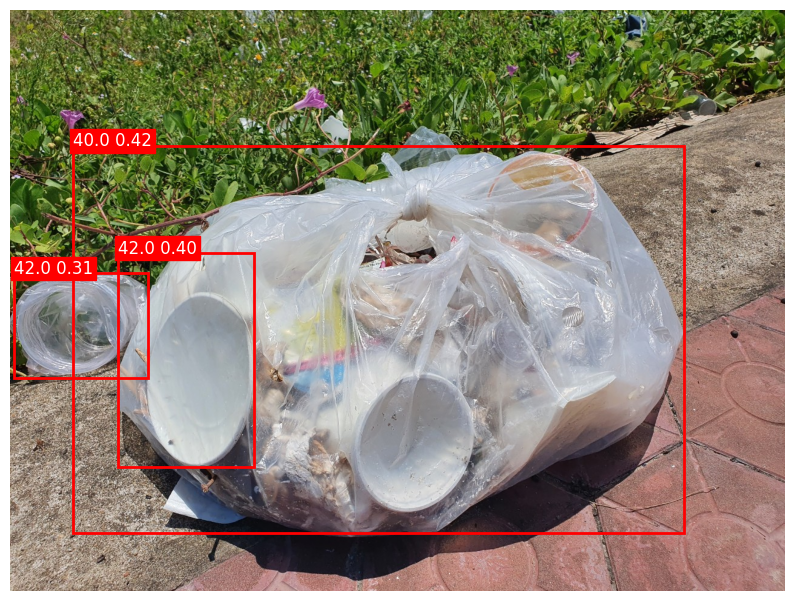

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

input_image_path = "/content/drive/MyDrive/Trash-paper-plastic-glass-CLS/plastic.webp"
image = Image.open(input_image_path)

train_model_path = "/content/drive/MyDrive/Trash-paper-plastic-glass-CLS/best10k.pt"

model = YOLO(train_model_path)
results = model.predict(source=input_image_path)

# Plot the image and draw the bounding boxes
plt.figure(figsize=(10, 10))
plt.imshow(image)
ax = plt.gca()

# Extract predictions
for result in results:
    # Extract bounding box coordinates
    boxes = result.boxes.xyxy.cpu().numpy()

    # Extract confidence scores
    scores = result.boxes.conf.cpu().numpy()

    # Extract class labels
    labels = result.boxes.cls.cpu().numpy()

    for box, score, label in zip(boxes, scores, labels):
        x1, y1, x2, y2 = box
        width, height = x2 - x1, y2 - y1

        # Draw the bounding box
        rect = plt.Rectangle((x1, y1), width, height, edgecolor='red', facecolor='none', linewidth=2)
        ax.add_patch(rect)

        # Draw the label and confidence
        plt.text(x1, y1, f'{label} {score:.2f}', color='white', fontsize=12, bbox=dict(facecolor='red', edgecolor='red', pad=2.0))

plt.axis('off')
plt.show()



image 1/1 /content/drive/MyDrive/Trash-paper-plastic-glass-CLS/plastic3.jpg: 384x480 1 clear_plastic_bottle, 1 other_plastic_wrapper, 10.5ms
Speed: 2.8ms preprocess, 10.5ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 480)


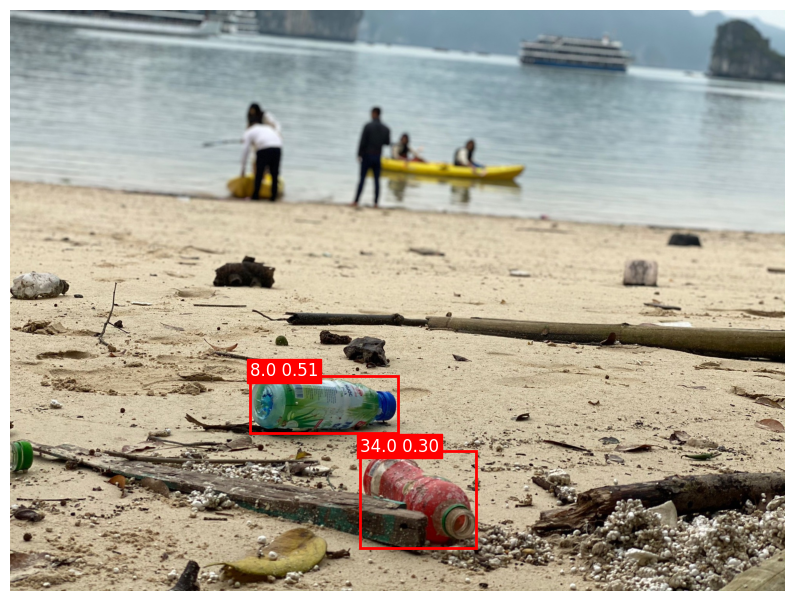

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

input_image_path = "/content/drive/MyDrive/Trash-paper-plastic-glass-CLS/plastic3.jpg"
image = Image.open(input_image_path)

train_model_path = "/content/drive/MyDrive/Trash-paper-plastic-glass-CLS/best10k.pt"

model = YOLO(train_model_path)
results = model.predict(source=input_image_path)

# Plot the image and draw the bounding boxes
plt.figure(figsize=(10, 10))
plt.imshow(image)
ax = plt.gca()

# Extract predictions
for result in results:
    # Extract bounding box coordinates
    boxes = result.boxes.xyxy.cpu().numpy()

    # Extract confidence scores
    scores = result.boxes.conf.cpu().numpy()

    # Extract class labels
    labels = result.boxes.cls.cpu().numpy()

    for box, score, label in zip(boxes, scores, labels):
        x1, y1, x2, y2 = box
        width, height = x2 - x1, y2 - y1

        # Draw the bounding box
        rect = plt.Rectangle((x1, y1), width, height, edgecolor='red', facecolor='none', linewidth=2)
        ax.add_patch(rect)

        # Draw the label and confidence
        plt.text(x1, y1, f'{label} {score:.2f}', color='white', fontsize=12, bbox=dict(facecolor='red', edgecolor='red', pad=2.0))

plt.axis('off')
plt.show()


In [2]:
import os

# Đường dẫn dataset
base_path = "/content/drive/MyDrive/yolov8s_trash/dataset"

# Các phần dữ liệu
splits = ["train", "val", "test"]

for split in splits:
    img_dir = os.path.join(base_path, split, "images")
    if os.path.exists(img_dir):
        # Đếm các file ảnh hợp lệ
        num_images = len([f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.jpeg', '.png'))])
        print(f"Số ảnh trong {split}/images: {num_images}")
    else:
        print(f"Không tìm thấy thư mục: {img_dir}")


Số ảnh trong train/images: 12312
Số ảnh trong val/images: 1422
Số ảnh trong test/images: 1424
